# <h1 style="color: yellow;">Neural Network Model (third alternative model)</h1>

## Libraries

In [28]:
#Call libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.tree import plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Training and tests variables import

In [29]:
#Import 80/20 model
import sys
sys.path.append("../")

from Variables.Training_test_variables_80_20 import (
    X,
    y,
    X_train,
    X_test,
    y_train,
    y_test
)

## One-Hot encoding

In [30]:
#Columns type identification
categorical_columns = X.select_dtypes(
    include=["object", "string"]
).columns.tolist() #-> 14

numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist() #-> 6

#Create the categorical columns preprocessing (the combination of values will result in 34 new categorical columns)
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_columns
     ),
        (
            "numerical",
            StandardScaler(),
            numerical_columns
        )
    ]
)
#Note:
   #The `handle_unknown="ignore"` setting is important. Imagine a category appearing in `X_test` that didn't exist in `X_train`. The encoder won't break.
   #StandardScaler() -> Standardizes numerical data by transforming the mean to zero and the standard deviation to one. Then, it places different variables on the same order of magnitude.

## Create the pipeline with neural network regression (model overview)

In [31]:
#Model neural (considering the preprocessor)
model_nn = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        max_iter=3000, #1000 -> 3000 because the model was not converging. The model is now converging with 3000 iterations.
        random_state=42
    ))
])

#Neural Network Settings: 
    #hidden_layer_sizes=(64, 32) -> Defines two hidden layers. The first has 64 neurons and the second has 32 neurons. 
    #activation="relu" -> Uses the ReLU activation function (commom function). It helps the network quickly learn complex, non-linear patterns. 
    #solver="adam" -> Weight optimization algorithm. Adam is efficient and handles large volumes of data well. 
    #max_iter=1000 -> Sets a maximum limit of 1000 epochs (training iterations) for the network to converge. 
    #random_state=42: Sets a fixed seed. Ensures the training produces the same result every time the code is run.
    #For other definitions 42 is "life, the universe, and everything else.

In [32]:
#Model training (fit)
model_nn.fit(X_train, y_train)
#Use X_train as the input variables and y_train as the correct values ​​to learn the relationship between them.

#Model prediction
y_pred_nn = model_nn.predict(X_test)
#X_test must remain separate to evaluate whether the model can generalize to data it did not use for learning.

## Using loss functions to validate the model (metrics comparison)

In [33]:
#Mean absolute error
mae_nn = mean_absolute_error(
    y_test,
    y_pred_nn
)

#Mean squared error
rmse_nn = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_nn
    )
)

#r2 error
r2_nn = r2_score(
    y_test,
    y_pred_nn
)

#r2 error adjusted
n = len(y_test)
p = X_test.shape[1]
adjusted_r2_nn = 1 - (1 - r2_nn) * (n - 1) / (n - p - 1)

print(f"MAE:  {mae_nn:.2f}")
print(f"RMSE: {rmse_nn:.2f}")
print(f"R²:   {r2_nn:.3f}")
print(f"Adjusted R²: {adjusted_r2_nn:.3f}")

MAE:  0.85
RMSE: 2.20
R²:   0.691
Adjusted R²: 0.686


In [34]:
#The neural network did not outperform our linear regression baseline.
#It is necessary to apply a hyperparameter tuning in this model to evaluate it. 
#Given that the adjusted R² is lower than the R² of the baseline model. 

## Tuned neural network (Hyperparameter Tuning)

### Using GridSearchCV

In [35]:
#Definition of parameters for the combinations
#We are using regresser because is a pipeline neural network
param_grid_nn = {
    "regressor__hidden_layer_sizes": [
        (32,),
        (64,),
        (128,),
        (64, 32),
        (128, 64)
    ],
    
    "regressor__activation": [
        "relu",
        "tanh"
    ],
    
    "regressor__alpha": [
        0.0001,
        0.001,
        0.01
    ],
    
    "regressor__learning_rate_init": [
        0.001,
        0.01
    ]
}

#Notes:
   #hidden_layer_sizes defines the architecture of the neural network. Each tuple represents a different configuration of hidden layers and their respective number of neurons.
   #relu and tanh are activation functions that introduce non-linearity into the model, allowing it to learn complex patterns.
   #alpha is a regularization parameter that helps prevent overfitting by penalizing large weights in the network.
   #learning_rate_init is the initial learning rate for weight updates. A smaller value can lead to more precise convergence, while a larger value can speed up training but may overshoot the optimal solution.

In [36]:
#Create GridSearchCV
grid_search_nn = GridSearchCV(
    estimator=model_nn,
    param_grid=param_grid_nn,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)
#Notes:
    #cv=5:
        #It stands for 5-fold cross-validation.
        #The training data will be split into 5 parts, and the model will be trained and tested multiple times to find a more robust configuration.
    #scoring="neg_root_mean_squared_error":
        #It means we are choosing the hyperparameters by aiming for the lowest RMSE.
    #n_jobs=-1 -> This allows the grid search to utilize all available CPU cores for parallel processing, speeding up the search process.
    #verbose=1 -> This will print out the progress of the grid search, so you can see how many combinations have been tried and how many are left.

In [37]:
#GridSearch training
grid_search_nn.fit(X_train, y_train)

#Grid:
   #5 architectures x 2 activation x 3 alpha × 2 learning rate = 60 combinações

Fitting 5 folds for each of 60 candidates, totalling 300 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'regressor__activation': ['relu', 'tanh'], 'regressor__alpha': [0.0001, 0.001, ...], 'regressor__hidden_layer_sizes': [(32,), (64,), ...], 'regressor__learning_rate_init': [0.001, 0.01]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scorin

In [ ]:
#Discovery of the best parameters and best score RMSE
print("Best parameters:")
print(grid_search_nn.best_params_)

print("Best CV RMSE:")
print(-grid_search_nn.best_score_)

Best parameters:
{'regressor__activation': 'relu', 'regressor__alpha': 0.01, 'regressor__hidden_layer_sizes': (32,), 'regressor__learning_rate_init': 0.01}
Best CV RMSE:
2.0312934526053867


### Make predictions using the best neural network

In [40]:
#GridSearchCV itself stores the best model
best_nn = grid_search_nn.best_estimator_
y_pred_nn_tuned = best_nn.predict(X_test)

### Using loss functions to validate the new model (metrics comparison)

In [43]:
#Mean absolute error
mae_nn_tuned = mean_absolute_error(
    y_test,
    y_pred_nn_tuned
)

#Mean squared error
rmse_nn_tuned = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_nn_tuned
    )
)

#r2 error
r2_nn_tuned = r2_score(
    y_test,
    y_pred_nn_tuned
)

#r2 error adjusted
n = len(y_test)
p = X_test.shape[1]
adjusted_r2_tuned = 1 - (1 - r2_nn_tuned) * (n - 1) / (n - p - 1)

print(f"MAE:  {mae_nn_tuned:.2f}")
print(f"RMSE: {rmse_nn_tuned:.2f}")
print(f"R²:   {r2_nn_tuned:.3f}")
print(f"Adjusted R²: {adjusted_r2_tuned:.3f}")

MAE:  0.46
RMSE: 2.05
R²:   0.732
Adjusted R²: 0.728


In [ ]:
#Notes:
   #Hyperparameter tuning significantly improved the Neural Network's performance,
   #reducing MAE from 0.85 to 0.46 and improving R² from 0.691 to 0.732.
   #The tuned model achieved performance close to the Linear Regression baseline.
   #Tuning significantly improved the Neural Network, reducing MAE from 0.85 to 0.46 (best)
   #and increasing R² from 0.691 to 0.732, bringing its performance close to the Linear Regression baseline.

{'regressor__activation': 'relu', 'regressor__alpha': 0.01, 'regressor__hidden_layer_sizes': (32,), 'regressor__learning_rate_init': 0.01}


In [46]:
#Best model extraction from GridSearchCV (neural network)
best_nn = grid_search_nn.best_estimator_
nn = best_nn.named_steps["regressor"]

print(nn)
print("Hidden layers:", nn.hidden_layer_sizes)
print("Number of layers:", nn.n_layers_)
print("Number of outputs:", nn.n_outputs_)

MLPRegressor(alpha=0.01, hidden_layer_sizes=(32,), learning_rate_init=0.01,
             max_iter=3000, random_state=42)
Hidden layers: (32,)
Number of layers: 3
Number of outputs: 1


In [ ]:
#For this dataset, 32 neurons in a single layer were apparently sufficient to capture the necessary relationships while avoiding unnecessary complexity.
#This also aligns well with the results we obtained: the tuned model achieved an MAE of 0.46 and an R² of 0.732—practically on par with Linear Regression.
#Number of layers -> Input + Hidden + Output (3 layers)

In [ ]:
#Layer weights visualization
for i, weights in enumerate(nn.coefs_):
    print(f"Layer {i + 1}:")
    print("Shape:", weights.shape)

Layer 1:
Shape: (40, 32)
Layer 2:
Shape: (32, 1)


In [ ]:
#First layer -> 40 inputs × 32 neurons = 1,280 weights
#The 32 neurons in the hidden layer contribute to producing the single final result (second layer -> 32 neurons × 1 output = 32 weights)

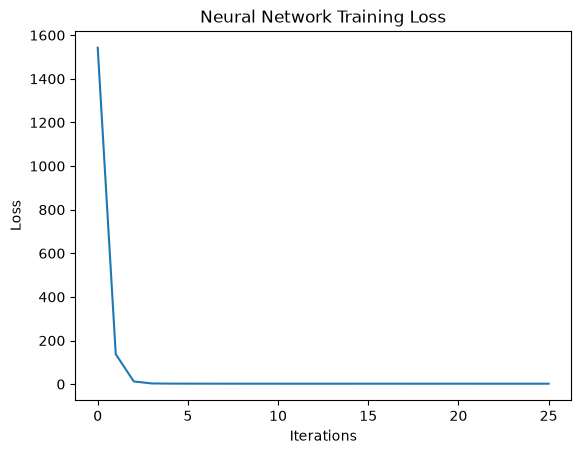

In [ ]:
#Training evolution visualization
plt.plot(nn.loss_curve_)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Neural Network Training Loss")
plt.show()

## Models metrics comparison

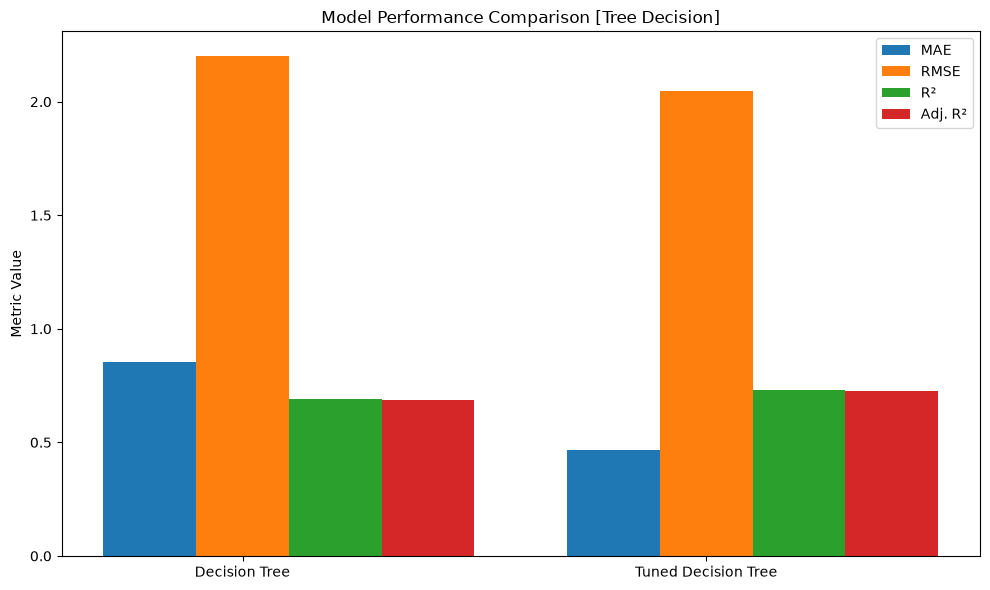

In [44]:
#Graph definition
models = [
    "Decision Tree",
    "Tuned Decision Tree"
]

mae_values = [mae_nn, mae_nn_tuned]
rmse_values = [rmse_nn, rmse_nn_tuned]
r2_values = [r2_nn, r2_nn_tuned]
adjusted_r2_values = [adjusted_r2_nn, adjusted_r2_tuned]

x = np.arange(len(models))
width = 0.20

plt.figure(figsize=(10, 6))

plt.bar(x - width, mae_values, width, label="MAE")
plt.bar(x, rmse_values, width, label="RMSE")
plt.bar(x + width, r2_values, width, label="R²")
plt.bar(x + width*2, adjusted_r2_values, width, label="Adj. R²")

plt.xticks(x, models)
plt.ylabel("Metric Value")
plt.title("Model Performance Comparison [Tree Decision]")
plt.legend()

plt.tight_layout()
plt.show()